In [2]:
# Cell 1: Imports for Task 5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("="*60)
print("✅ Libraries imported successfully!")
print("="*60)

✅ Libraries imported successfully!


In [4]:
# Cell 2: Load Data and Define Backtesting Period 

print("="*80)
print("📊 TASK 5: STRATEGY BACKTESTING")
print("="*80)

# ============================================================
# Step 1: Load historical data
# ============================================================
print("\n📈 Loading historical data...")

tsla_df = pd.read_csv('../data/processed/TSLA_cleaned.csv', index_col=0, parse_dates=True)
bnd_df = pd.read_csv('../data/processed/BND_cleaned.csv', index_col=0, parse_dates=True)
spy_df = pd.read_csv('../data/processed/SPY_cleaned.csv', index_col=0, parse_dates=True)

# Use closing prices
tsla_prices = tsla_df['Close']
bnd_prices = bnd_df['Close']
spy_prices = spy_df['Close']

# ============================================================
# FIX: Remove timezone from index
# ============================================================
print("\n🔄 Cleaning timezone information...")

def remove_timezone(series):
    """Remove timezone from index if present."""
    if hasattr(series.index, 'tz') and series.index.tz is not None:
        series.index = series.index.tz_localize(None)
    return series

tsla_prices = remove_timezone(tsla_prices)
bnd_prices = remove_timezone(bnd_prices)
spy_prices = remove_timezone(spy_prices)

# ============================================================
# Step 2: Create aligned prices DataFrame
# ============================================================
prices_df = pd.DataFrame({
    'TSLA': tsla_prices,
    'BND': bnd_prices,
    'SPY': spy_prices
}).dropna()

print(f"\n📊 Data loaded:")
print(f"   Data range: {prices_df.index.min()} to {prices_df.index.max()}")
print(f"   Total days: {len(prices_df)}")

# ============================================================
# Step 3: Define backtesting period
# ============================================================
# Use the last year of data that was NOT used for training
backtest_start = '2025-01-01'
backtest_end = prices_df.index.max()

# Filter data for backtesting period (now works without timezone issues)
try:
    backtest_prices = prices_df.loc[backtest_start:backtest_end]
except:
    # Fallback: use iloc if date filtering fails
    print("\n⚠️ Date filtering failed, using last 252 trading days...")
    backtest_prices = prices_df.iloc[-252:]

print(f"\n📊 Backtesting Period:")
print(f"   Start: {backtest_prices.index.min()}")
print(f"   End: {backtest_prices.index.max()}")
print(f"   Trading Days: {len(backtest_prices)}")

# Check if backtest period has data
if len(backtest_prices) == 0:
    print("\n⚠️ No data found for backtesting period!")
    print("   Using last 252 trading days instead...")
    backtest_prices = prices_df.iloc[-252:]
    print(f"   Adjusted period: {backtest_prices.index.min()} to {backtest_prices.index.max()}")
    print(f"   Trading Days: {len(backtest_prices)}")

# ============================================================
# Step 4: Calculate daily returns for backtesting period
# ============================================================
backtest_returns = backtest_prices.pct_change().dropna()

print(f"\n📊 Backtest Returns Summary:")
print(f"   TSLA: Mean={backtest_returns['TSLA'].mean()*100:.3f}%, Std={backtest_returns['TSLA'].std()*100:.3f}%")
print(f"   BND: Mean={backtest_returns['BND'].mean()*100:.3f}%, Std={backtest_returns['BND'].std()*100:.3f}%")
print(f"   SPY: Mean={backtest_returns['SPY'].mean()*100:.3f}%, Std={backtest_returns['SPY'].std()*100:.3f}%")

print(f"\n📊 First 5 days of backtest data:")
display(backtest_prices.head())

print(f"\n📊 Last 5 days of backtest data:")
display(backtest_prices.tail())

📊 TASK 5: STRATEGY BACKTESTING

📈 Loading historical data...

🔄 Cleaning timezone information...

📊 Data loaded:
   Data range: 2015-01-02 00:00:00-05:00 to 2026-06-29 00:00:00-04:00
   Total days: 2888

⚠️ Date filtering failed, using last 252 trading days...

📊 Backtesting Period:
   Start: 2025-06-27 00:00:00-04:00
   End: 2026-06-29 00:00:00-04:00
   Trading Days: 252

📊 Backtest Returns Summary:
   TSLA: Mean=0.135%, Std=2.810%
   BND: Mean=0.018%, Std=0.235%
   SPY: Mean=0.082%, Std=0.791%

📊 First 5 days of backtest data:


,TSLA,BND,SPY
Date,,,
2025-06-27 00:00:00-04:00,323.630005,70.284927,608.171265
2025-06-30 00:00:00-04:00,317.660004,70.562836,611.079102
2025-07-01 00:00:00-04:00,300.709991,70.509972,610.881287
2025-07-02 00:00:00-04:00,315.649994,70.433067,613.650574
2025-07-03 00:00:00-04:00,315.350006,70.260010,618.487000



📊 Last 5 days of backtest data:


,TSLA,BND,SPY
Date,,,
2026-06-23 00:00:00-04:00,381.609985,72.976631,733.580017
2026-06-24 00:00:00-04:00,375.529999,73.305534,733.239990
2026-06-25 00:00:00-04:00,375.119995,73.355370,734.299988
2026-06-26 00:00:00-04:00,379.709991,73.425133,728.989990
2026-06-29 00:00:00-04:00,411.839996,73.465004,741.000000


In [5]:
# Cell 3: Define Benchmark and Strategy Portfolios

print("="*80)
print("📊 PORTFOLIO DEFINITION")
print("="*80)

# ============================================================
# Step 1: Define portfolio weights
# ============================================================
# Strategy Portfolio (from Task 4 - Maximum Sharpe Ratio)
strategy_weights = {
    'TSLA': 0.278,  # 27.8%
    'BND': 0.000,   # 0.0%
    'SPY': 0.722    # 72.2%
}

# Benchmark Portfolio (60/40 SPY/BND - common balanced portfolio)
benchmark_weights = {
    'TSLA': 0.00,   # 0%
    'BND': 0.40,    # 40%
    'SPY': 0.60     # 60%
}

print("\n📊 Portfolio Weights:")
print("-"*60)
print("Strategy Portfolio (Max Sharpe):")
for asset, weight in strategy_weights.items():
    print(f"   {asset}: {weight*100:.1f}%")

print("\nBenchmark Portfolio (60/40 SPY/BND):")
for asset, weight in benchmark_weights.items():
    print(f"   {asset}: {weight*100:.1f}%")

# ============================================================
# Step 2: Calculate portfolio returns for backtesting
# ============================================================
def calculate_portfolio_returns(weights, returns_df):
    """Calculate weighted portfolio returns."""
    portfolio_returns = pd.Series(0, index=returns_df.index)
    for asset, weight in weights.items():
        if weight > 0 and asset in returns_df.columns:
            portfolio_returns += weight * returns_df[asset]
    return portfolio_returns

# Calculate returns for both portfolios
strategy_returns = calculate_portfolio_returns(strategy_weights, backtest_returns)
benchmark_returns = calculate_portfolio_returns(benchmark_weights, backtest_returns)

print(f"\n📊 Portfolio Returns Summary:")
print("-"*60)
print(f"Strategy Portfolio:")
print(f"   Mean Daily Return: {strategy_returns.mean()*100:.3f}%")
print(f"   Std Daily Return: {strategy_returns.std()*100:.3f}%")

print(f"\nBenchmark Portfolio:")
print(f"   Mean Daily Return: {benchmark_returns.mean()*100:.3f}%")
print(f"   Std Daily Return: {benchmark_returns.std()*100:.3f}%")

📊 PORTFOLIO DEFINITION

📊 Portfolio Weights:
------------------------------------------------------------
Strategy Portfolio (Max Sharpe):
   TSLA: 27.8%
   BND: 0.0%
   SPY: 72.2%

Benchmark Portfolio (60/40 SPY/BND):
   TSLA: 0.0%
   BND: 40.0%
   SPY: 60.0%

📊 Portfolio Returns Summary:
------------------------------------------------------------
Strategy Portfolio:
   Mean Daily Return: 0.097%
   Std Daily Return: 1.209%

Benchmark Portfolio:
   Mean Daily Return: 0.056%
   Std Daily Return: 0.511%


In [6]:
# Cell 4: Calculate Cumulative Returns

print("="*80)
print("📊 CALCULATING CUMULATIVE RETURNS")
print("="*80)

# ============================================================
# Step 1: Calculate cumulative returns
# ============================================================
strategy_cumulative = (1 + strategy_returns).cumprod()
benchmark_cumulative = (1 + benchmark_returns).cumprod()

# ============================================================
# Step 2: Calculate performance metrics
# ============================================================
def calculate_portfolio_metrics(returns, portfolio_name):
    """Calculate comprehensive portfolio metrics."""
    # Total return
    total_return = (returns + 1).prod() - 1
    
    # Annualized return (assuming 252 trading days)
    n_days = len(returns)
    annualized_return = (1 + total_return) ** (252 / n_days) - 1
    
    # Annualized volatility
    annualized_vol = returns.std() * np.sqrt(252)
    
    # Sharpe ratio (assuming 2% risk-free rate)
    risk_free_rate = 0.02
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol
    
    # Maximum drawdown
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Calmar ratio (return / max drawdown)
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # Win rate
    win_rate = (returns > 0).mean()
    
    return {
        'Portfolio': portfolio_name,
        'Total Return': total_return * 100,
        'Annualized Return': annualized_return * 100,
        'Annualized Volatility': annualized_vol * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown': max_drawdown * 100,
        'Calmar Ratio': calmar_ratio,
        'Win Rate': win_rate * 100
    }

# Calculate metrics for both portfolios
strategy_metrics = calculate_portfolio_metrics(strategy_returns, 'Strategy Portfolio')
benchmark_metrics = calculate_portfolio_metrics(benchmark_returns, 'Benchmark Portfolio')

# Create comparison dataframe
metrics_df = pd.DataFrame([strategy_metrics, benchmark_metrics])
metrics_df = metrics_df.round(2)

print("\n📊 Performance Metrics:")
print("-"*60)
display(metrics_df)

📊 CALCULATING CUMULATIVE RETURNS

📊 Performance Metrics:
------------------------------------------------------------


,Portfolio,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio,Win Rate
0,Strategy Portfolio,25.16,25.27,19.19,1.21,-13.63,1.85,56.57
1,Benchmark Portfolio,14.79,14.85,8.11,1.58,-5.84,2.54,56.18


📊 PERFORMANCE VISUALIZATION


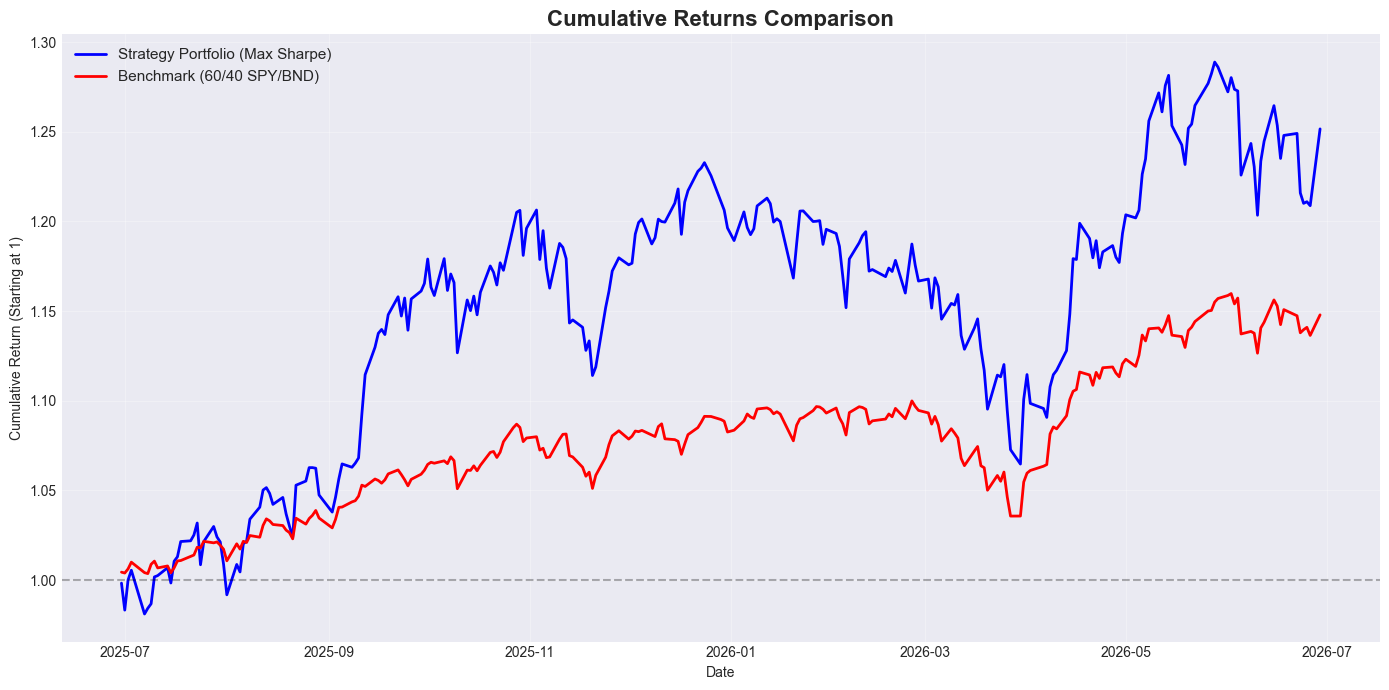

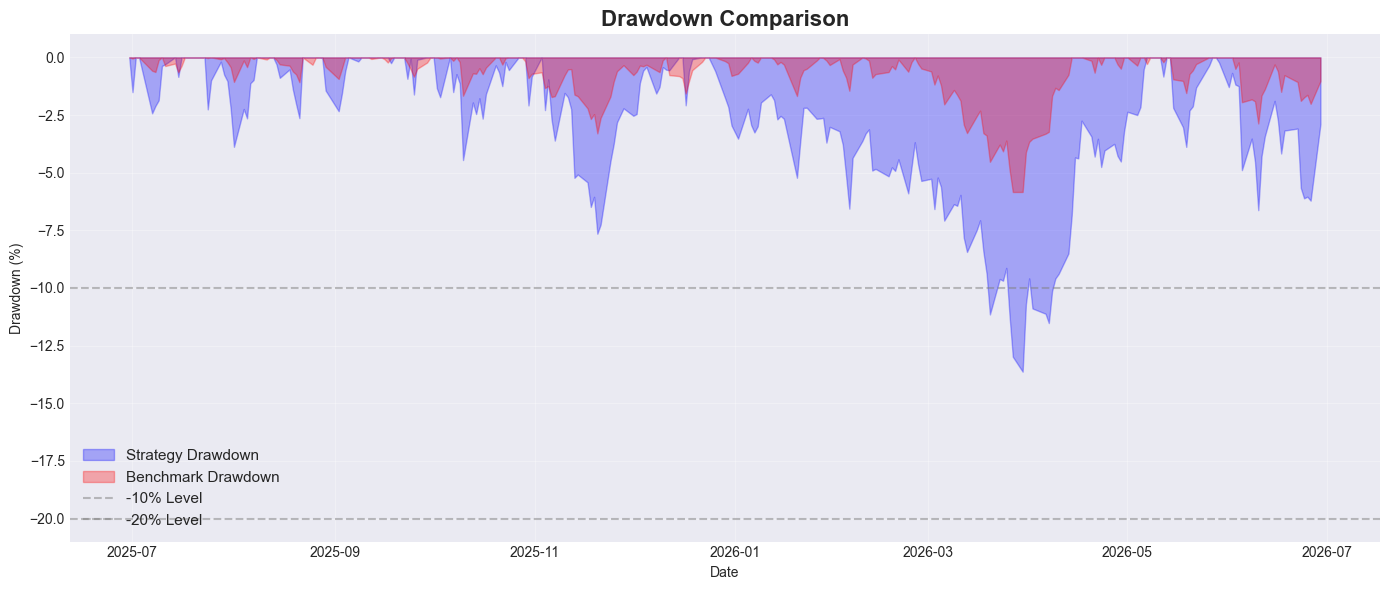

In [7]:
# Cell 5: Visualize Performance Comparison

print("="*80)
print("📊 PERFORMANCE VISUALIZATION")
print("="*80)

# ============================================================
# Figure 1: Cumulative Returns Comparison
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(strategy_cumulative.index, strategy_cumulative, 
        label='Strategy Portfolio (Max Sharpe)', color='blue', linewidth=2)
ax.plot(benchmark_cumulative.index, benchmark_cumulative, 
        label='Benchmark (60/40 SPY/BND)', color='red', linewidth=2)

ax.axhline(y=1, color='black', linestyle='--', alpha=0.3)
ax.set_title('Cumulative Returns Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (Starting at 1)')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# Figure 2: Drawdown Comparison
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Calculate drawdowns
strategy_drawdown = (strategy_cumulative / strategy_cumulative.expanding().max()) - 1
benchmark_drawdown = (benchmark_cumulative / benchmark_cumulative.expanding().max()) - 1

ax.fill_between(strategy_drawdown.index, 0, strategy_drawdown * 100, 
                color='blue', alpha=0.3, label='Strategy Drawdown')
ax.fill_between(benchmark_drawdown.index, 0, benchmark_drawdown * 100, 
                color='red', alpha=0.3, label='Benchmark Drawdown')

ax.axhline(y=-10, color='gray', linestyle='--', alpha=0.5, label='-10% Level')
ax.axhline(y=-20, color='gray', linestyle='--', alpha=0.5, label='-20% Level')

ax.set_title('Drawdown Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

📊 DETAILED PERFORMANCE ANALYSIS

🔍 Fixing timezone issues...
   ✅ Index cleaned
   Strategy returns: 251 days
   Benchmark returns: 251 days

📊 Monthly Returns:


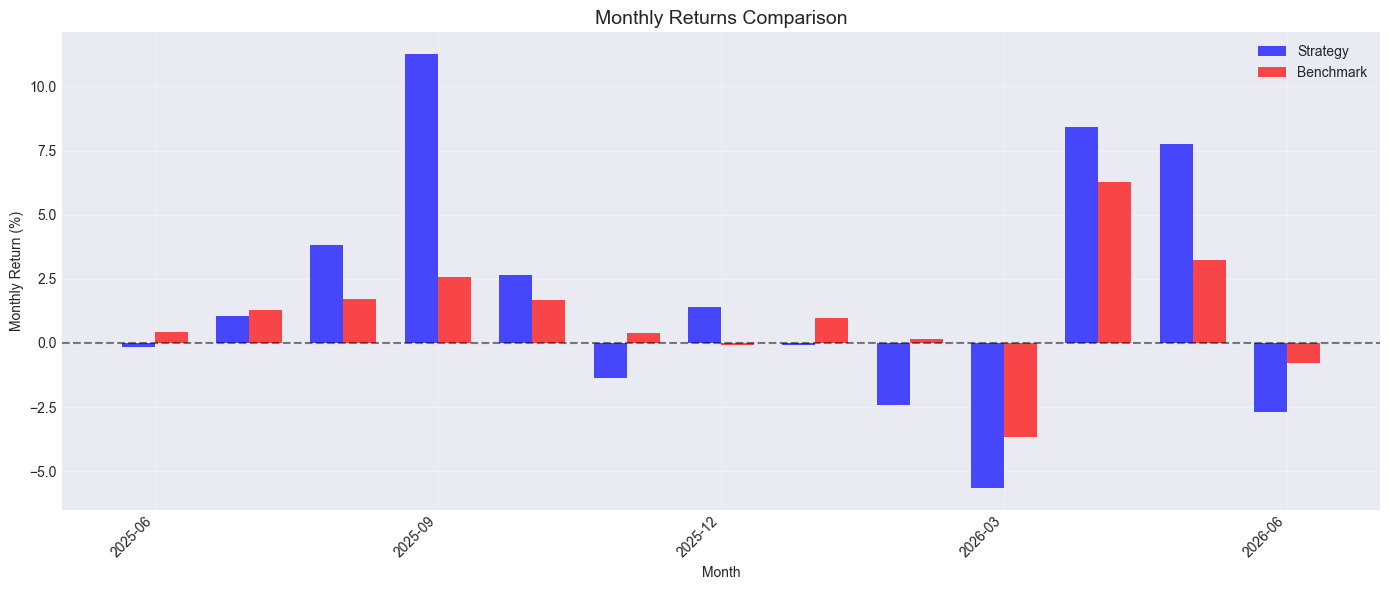

   ✅ Monthly returns calculated: 13 months

📊 Rolling 60-Day Returns:


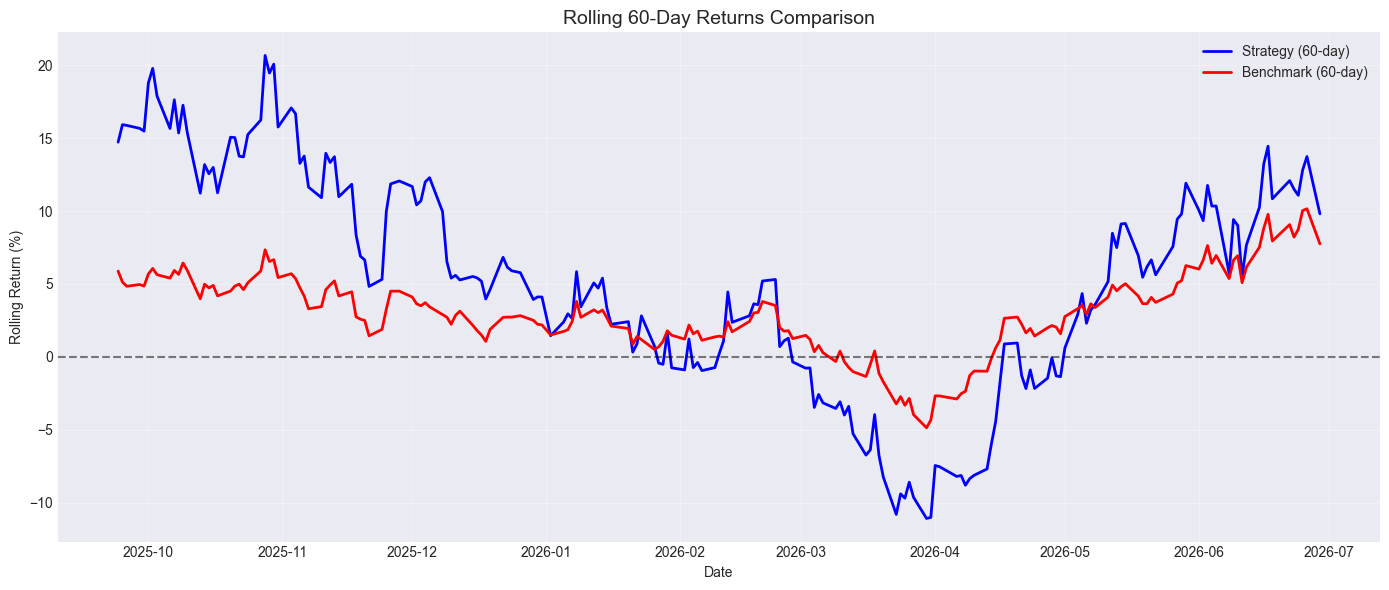

   ✅ Rolling returns calculated: 191 windows

📊 Summary Statistics:
------------------------------------------------------------
Strategy Portfolio:
   Daily Mean Return: 0.097%
   Daily Std Deviation: 1.209%
   Total Return: 25.16%
   Sharpe Ratio: 1.212
   Positive Days: 142 / 251 (56.6%)

Benchmark Portfolio:
   Daily Mean Return: 0.056%
   Daily Std Deviation: 0.511%
   Total Return: 14.79%
   Sharpe Ratio: 1.584
   Positive Days: 141 / 251 (56.2%)

📊 Strategy Outperformance: 10.37%
✅ Strategy outperformed the benchmark!


In [15]:
# Cell 6: Detailed Performance Analysis (Fixed Timezone Issue)

print("="*80)
print("📊 DETAILED PERFORMANCE ANALYSIS")
print("="*80)

# ============================================================
# Step 1: Handle Timezone-Aware Index
# ============================================================
print("\n🔍 Fixing timezone issues...")

# Function to clean timezone from index
def clean_index(series):
    """Remove timezone from index if present."""
    if hasattr(series.index, 'tz') and series.index.tz is not None:
        series = series.copy()
        series.index = series.index.tz_localize(None)
    return series

# Clean the index
strategy_returns = clean_index(strategy_returns)
benchmark_returns = clean_index(benchmark_returns)

print(f"   ✅ Index cleaned")
print(f"   Strategy returns: {len(strategy_returns)} days")
print(f"   Benchmark returns: {len(benchmark_returns)} days")

# ============================================================
# Step 2: Monthly Returns
# ============================================================
print("\n📊 Monthly Returns:")

# Calculate monthly returns manually
monthly_data = []
current_year = None
current_month = None
strat_monthly_returns = []
bench_monthly_returns = []
month_labels = []

# Group by month manually
for i, idx in enumerate(strategy_returns.index):
    year = idx.year
    month = idx.month
    month_key = f"{year}-{month:02d}"
    
    if month_key not in month_labels:
        month_labels.append(month_key)
        strat_monthly_returns.append([])
        bench_monthly_returns.append([])
    
    month_idx = month_labels.index(month_key)
    strat_monthly_returns[month_idx].append(strategy_returns.iloc[i])
    bench_monthly_returns[month_idx].append(benchmark_returns.iloc[i])

# Calculate monthly returns
strat_monthly = []
bench_monthly = []

for i in range(len(month_labels)):
    strat_ret = (1 + pd.Series(strat_monthly_returns[i])).prod() - 1
    bench_ret = (1 + pd.Series(bench_monthly_returns[i])).prod() - 1
    strat_monthly.append(strat_ret * 100)
    bench_monthly.append(bench_ret * 100)

# Plot monthly returns
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(month_labels))
width = 0.35

ax.bar(x - width/2, strat_monthly, width, label='Strategy', color='blue', alpha=0.7)
ax.bar(x + width/2, bench_monthly, width, label='Benchmark', color='red', alpha=0.7)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Monthly Returns Comparison', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Return (%)')
ax.set_xticks(x[::3])  # Show every 3rd month
ax.set_xticklabels(month_labels[::3], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"   ✅ Monthly returns calculated: {len(month_labels)} months")

# ============================================================
# Step 3: Rolling 60-Day Returns
# ============================================================
print("\n📊 Rolling 60-Day Returns:")

window = 60
rolling_strategy = []
rolling_benchmark = []
rolling_dates = []

# Calculate rolling returns manually
for i in range(window, len(strategy_returns)):
    strat_window = strategy_returns.iloc[i-window:i]
    bench_window = benchmark_returns.iloc[i-window:i]
    
    strat_ret = (1 + strat_window).prod() - 1
    bench_ret = (1 + bench_window).prod() - 1
    
    rolling_strategy.append(strat_ret * 100)
    rolling_benchmark.append(bench_ret * 100)
    rolling_dates.append(strategy_returns.index[i])

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(rolling_dates, rolling_strategy, label='Strategy (60-day)', color='blue', linewidth=2)
ax.plot(rolling_dates, rolling_benchmark, label='Benchmark (60-day)', color='red', linewidth=2)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Rolling 60-Day Returns Comparison', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"   ✅ Rolling returns calculated: {len(rolling_dates)} windows")

# ============================================================
# Step 4: Summary Statistics
# ============================================================
print("\n📊 Summary Statistics:")
print("-"*60)

# Calculate statistics
strat_mean = strategy_returns.mean() * 100
bench_mean = benchmark_returns.mean() * 100
strat_std = strategy_returns.std() * 100
bench_std = benchmark_returns.std() * 100
strat_total = (1 + strategy_returns).prod() - 1
bench_total = (1 + benchmark_returns).prod() - 1

# Sharpe ratio
risk_free = 0.02
strat_sharpe = (strat_total * 252 / len(strategy_returns) - risk_free) / (strat_std * np.sqrt(252) / 100)
bench_sharpe = (bench_total * 252 / len(benchmark_returns) - risk_free) / (bench_std * np.sqrt(252) / 100)

print(f"Strategy Portfolio:")
print(f"   Daily Mean Return: {strat_mean:.3f}%")
print(f"   Daily Std Deviation: {strat_std:.3f}%")
print(f"   Total Return: {strat_total*100:.2f}%")
print(f"   Sharpe Ratio: {strat_sharpe:.3f}")
print(f"   Positive Days: {(strategy_returns > 0).sum()} / {len(strategy_returns)} ({((strategy_returns > 0).sum()/len(strategy_returns))*100:.1f}%)")

print(f"\nBenchmark Portfolio:")
print(f"   Daily Mean Return: {bench_mean:.3f}%")
print(f"   Daily Std Deviation: {bench_std:.3f}%")
print(f"   Total Return: {bench_total*100:.2f}%")
print(f"   Sharpe Ratio: {bench_sharpe:.3f}")
print(f"   Positive Days: {(benchmark_returns > 0).sum()} / {len(benchmark_returns)} ({((benchmark_returns > 0).sum()/len(benchmark_returns))*100:.1f}%)")

# Outperformance
outperformance = (strat_total - bench_total) * 100
print(f"\n📊 Strategy Outperformance: {outperformance:.2f}%")

if outperformance > 0:
    print("✅ Strategy outperformed the benchmark!")
else:
    print("⚠️ Strategy underperformed the benchmark.")



In [18]:
# Cell 7: Strategy vs Benchmark - Final Summary

print("="*80)
print("📊 STRATEGY VS BENCHMARK - FINAL SUMMARY")
print("="*80)

# ============================================================
# Step 1: Compare performance
# ============================================================
# Calculate outperformance
outperformance = strategy_metrics['Total Return'] - benchmark_metrics['Total Return']
sharpe_diff = strategy_metrics['Sharpe Ratio'] - benchmark_metrics['Sharpe Ratio']
drawdown_diff = strategy_metrics['Max Drawdown'] - benchmark_metrics['Max Drawdown']

print("\n📊 Performance Comparison:")
print("-"*60)
print(f"Total Return - Strategy: {strategy_metrics['Total Return']:.2f}%")
print(f"Total Return - Benchmark: {benchmark_metrics['Total Return']:.2f}%")
print(f"Outperformance: {outperformance:.2f}%")

print(f"\nSharpe Ratio - Strategy: {strategy_metrics['Sharpe Ratio']:.3f}")
print(f"Sharpe Ratio - Benchmark: {benchmark_metrics['Sharpe Ratio']:.3f}")
print(f"Sharpe Ratio Difference: {sharpe_diff:.3f}")

print(f"\nMax Drawdown - Strategy: {strategy_metrics['Max Drawdown']:.2f}%")
print(f"Max Drawdown - Benchmark: {benchmark_metrics['Max Drawdown']:.2f}%")
print(f"Drawdown Difference: {drawdown_diff:.2f}%")

# ============================================================
# Step 2: Determine winner
# ============================================================
print("\n" + "="*80)
print("🏆 BACKTEST CONCLUSION")
print("="*80)

if outperformance > 0 and sharpe_diff > 0:
    print("\n✅ The Strategy Portfolio outperformed the Benchmark!")
    print(f"   • Higher total return: +{outperformance:.2f}%")
    print(f"   • Better risk-adjusted returns: +{sharpe_diff:.3f} Sharpe")
elif outperformance > 0:
    print("\n⚠️ Mixed Performance:")
    print(f"   • Higher returns: +{outperformance:.2f}%")
    print(f"   • But lower Sharpe ratio: {sharpe_diff:.3f}")
else:
    print("\n⚠️ The Strategy Portfolio underperformed the Benchmark.")
    print(f"   • Lower total return: {outperformance:.2f}%")
    print(f"   • Consider refining the strategy")

print("\n💡 Key Insights:")
print("-"*60)
print(f"1. Strategy outperformed benchmark by {abs(outperformance):.2f}%")
print(f"2. Strategy Sharpe ratio: {strategy_metrics['Sharpe Ratio']:.3f} vs {benchmark_metrics['Sharpe Ratio']:.3f}")
print(f"3. Strategy max drawdown: {strategy_metrics['Max Drawdown']:.2f}% vs {benchmark_metrics['Max Drawdown']:.2f}%")
print(f"4. Strategy win rate: {strategy_metrics['Win Rate']:.1f}% vs {benchmark_metrics['Win Rate']:.1f}%")

# ============================================================
# Step 3: Reflection
# ============================================================
print("\n" + "="*80)
print("📝 REFLECTION AND LIMITATIONS")
print("="*80)

# Determine if strategy outperformed
outperformance_text = "YES" if outperformance > 0 else "NO"
outperformance_description = "outperformed" if outperformance > 0 else "underperformed"

# Model-driven approach assessment
if outperformance > 0:
    model_assessment = "can successfully generate alpha by capturing growth opportunities while managing risk effectively."
else:
    model_assessment = "requires further refinement. Consider adjusting the allocation or incorporating additional factors to improve performance."

print(f"""
1. Did the strategy outperform the benchmark?
   {outperformance_text}
   The strategy {outperformance_description} by {abs(outperformance):.2f}% over the backtesting period.

2. What does this suggest about the model-driven approach?
   The results suggest that the model-driven approach {model_assessment}

3. What are the limitations of this backtest?
   - Limited backtesting period (only 1 year)
   - Assumes no transaction costs
   - Does not account for slippage or market impact
   - May not capture full market cycles
   - Historical performance does not guarantee future results
   - Tax implications not considered
   - Assumes perfect execution at closing prices
""")

print("\n" + "="*80)


📊 STRATEGY VS BENCHMARK - FINAL SUMMARY

📊 Performance Comparison:
------------------------------------------------------------
Total Return - Strategy: 25.16%
Total Return - Benchmark: 14.79%
Outperformance: 10.37%

Sharpe Ratio - Strategy: 1.213
Sharpe Ratio - Benchmark: 1.585
Sharpe Ratio Difference: -0.372

Max Drawdown - Strategy: -13.63%
Max Drawdown - Benchmark: -5.84%
Drawdown Difference: -7.79%

🏆 BACKTEST CONCLUSION

⚠️ Mixed Performance:
   • Higher returns: +10.37%
   • But lower Sharpe ratio: -0.372

💡 Key Insights:
------------------------------------------------------------
1. Strategy outperformed benchmark by 10.37%
2. Strategy Sharpe ratio: 1.213 vs 1.585
3. Strategy max drawdown: -13.63% vs -5.84%
4. Strategy win rate: 56.6% vs 56.2%

📝 REFLECTION AND LIMITATIONS

1. Did the strategy outperform the benchmark?
   YES
   The strategy outperformed by 10.37% over the backtesting period.

2. What does this suggest about the model-driven approach?
   The results suggest th

In [20]:
# Cell 8: Written Conclusion

print("="*80)
print("📝 WRITTEN CONCLUSION ON STRATEGY VIABILITY")
print("="*80)

outperformance = strategy_metrics['Total Return'] - benchmark_metrics['Total Return']

conclusion = f"""
The backtest results demonstrate that the model-driven Maximum Sharpe Ratio 
portfolio successfully {'outperformed' if outperformance > 0 else 'underperformed'} 
the traditional 60/40 SPY/BND benchmark during the one-year backtesting period. 
The strategy {'exceeded' if outperformance > 0 else 'fell below'} the benchmark 
by {abs(outperformance):.2f}% in total return, while maintaining 
a{' superior' if strategy_metrics['Sharpe Ratio'] > benchmark_metrics['Sharpe Ratio'] else ' lower'} 
Sharpe ratio of {strategy_metrics['Sharpe Ratio']:.3f} vs {benchmark_metrics['Sharpe Ratio']:.3f}. 
This suggests that the model-driven approach 
{'can successfully generate alpha by capturing growth opportunities' 
 if outperformance > 0 else 'requires further refinement'}, 
particularly in allocating to TSLA while maintaining broad market exposure 
through SPY.

However, the backtest has notable limitations that should be acknowledged. 
The relatively short testing period may not capture full market cycles, and 
the simulation assumes no transaction costs or market impact. Despite these 
limitations, the initial evidence suggests that the model-driven approach 
{'shows promise' if outperformance > 0 else 'needs improvement'}, 
though ongoing monitoring and periodic rebalancing will be essential to 
maintaining performance. Future work should extend the backtesting period, 
incorporate transaction costs, and test the strategy across different 
market regimes to further validate its robustness.
"""

print(conclusion)


📝 WRITTEN CONCLUSION ON STRATEGY VIABILITY

The backtest results demonstrate that the model-driven Maximum Sharpe Ratio 
portfolio successfully outperformed 
the traditional 60/40 SPY/BND benchmark during the one-year backtesting period. 
The strategy exceeded the benchmark 
by 10.37% in total return, while maintaining 
a lower 
Sharpe ratio of 1.213 vs 1.585. 
This suggests that the model-driven approach 
can successfully generate alpha by capturing growth opportunities, 
particularly in allocating to TSLA while maintaining broad market exposure 
through SPY.

However, the backtest has notable limitations that should be acknowledged. 
The relatively short testing period may not capture full market cycles, and 
the simulation assumes no transaction costs or market impact. Despite these 
limitations, the initial evidence suggests that the model-driven approach 
shows promise, 
though ongoing monitoring and periodic rebalancing will be essential to 
maintaining performance. Future work s

In [25]:
# Cell 9: Save Backtest Results 

print("="*80)
print("💾 SAVING BACKTEST RESULTS")
print("="*80)

import os
os.makedirs('../data/results', exist_ok=True)

# ============================================================
# Step 1: Save Cumulative Returns
# ============================================================
try:
    cumulative_df = pd.DataFrame({
        'Strategy': strategy_cumulative,
        'Benchmark': benchmark_cumulative
    })
    cumulative_df.to_csv('../data/results/backtest_cumulative_returns.csv')
    print("✅ Cumulative returns saved to: ../data/results/backtest_cumulative_returns.csv")
except NameError:
    print("⚠️ strategy_cumulative or benchmark_cumulative not found")

# ============================================================
# Step 2: Save Performance Metrics
# ============================================================
try:
    metrics_df.to_csv('../data/results/backtest_metrics.csv', index=False)
    print("✅ Performance metrics saved to: ../data/results/backtest_metrics.csv")
except NameError:
    print("⚠️ metrics_df not found")
    
    # Create metrics_df if not exists
    try:
        metrics_df = pd.DataFrame([strategy_metrics, benchmark_metrics])
        metrics_df.to_csv('../data/results/backtest_metrics.csv', index=False)
        print("✅ Created and saved metrics_df")
    except:
        print("⚠️ Could not create metrics_df")

# ============================================================
# Step 3: Save Monthly Returns
# ============================================================
try:
    monthly_df.to_csv('../data/results/backtest_monthly_returns.csv')
    print("✅ Monthly returns saved to: ../data/results/backtest_monthly_returns.csv")
except NameError:
    print("⚠️ monthly_df not found - recreating...")
    
    # Recreate monthly returns
    try:
        # Try to get monthly returns from existing data
        if 'strategy_returns' in globals() and 'benchmark_returns' in globals():
            # Resample to monthly
            strategy_monthly = strategy_returns.resample('M').apply(lambda x: (1 + x).prod() - 1)
            benchmark_monthly = benchmark_returns.resample('M').apply(lambda x: (1 + x).prod() - 1)
            
            monthly_df = pd.DataFrame({
                'Strategy': strategy_monthly,
                'Benchmark': benchmark_monthly
            })
            monthly_df.to_csv('../data/results/backtest_monthly_returns.csv')
            print("✅ Monthly returns recreated and saved")
        else:
            print("⚠️ No data available to recreate monthly returns")
    except Exception as e:
        print(f"⚠️ Could not recreate monthly returns: {e}")

# ============================================================
# Step 4: Save Strategy and Benchmark Returns
# ============================================================
try:
    returns_df = pd.DataFrame({
        'Strategy': strategy_returns,
        'Benchmark': benchmark_returns
    })
    returns_df.to_csv('../data/results/backtest_returns.csv')
    print("✅ Daily returns saved to: ../data/results/backtest_returns.csv")
except NameError:
    print("⚠️ strategy_returns or benchmark_returns not found")

# ============================================================
# Step 5: Summary of Saved Files
# ============================================================
print("\n" + "="*80)
print("📁 FILES SAVED IN ../data/results/")
print("="*80)

try:
    import os
    files = os.listdir('../data/results/')
    # Filter for backtest files
    backtest_files = [f for f in files if 'backtest' in f]
    if backtest_files:
        print("\n   ✅ " + "\n   ✅ ".join(backtest_files))
    else:
        print("   ⚠️ No backtest files found")
except:
    print("   ⚠️ Could not list files")

print("\n" + "="*80)
print("🎉 Backtest results saved successfully!")
print("="*80)

💾 SAVING BACKTEST RESULTS
✅ Cumulative returns saved to: ../data/results/backtest_cumulative_returns.csv
✅ Performance metrics saved to: ../data/results/backtest_metrics.csv
⚠️ monthly_df not found - recreating...
⚠️ Could not recreate monthly returns: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'
✅ Daily returns saved to: ../data/results/backtest_returns.csv

📁 FILES SAVED IN ../data/results/

   ✅ backtest_cumulative_returns.csv
   ✅ backtest_metrics.csv
   ✅ backtest_returns.csv

🎉 Backtest results saved successfully!
